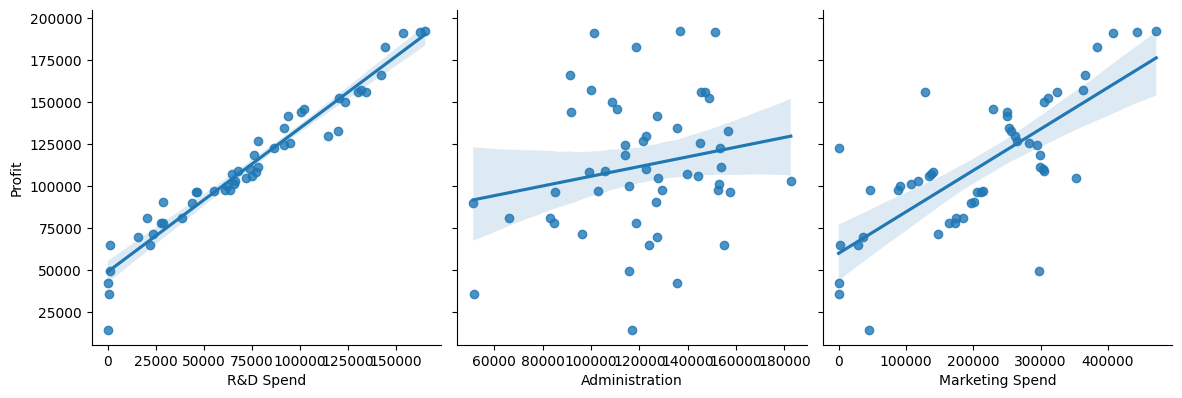

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Example: Load your dataset (replace with your actual data loading code)
data = pd.read_csv('/content/50_Startups.csv')


# Visualize pairwise relationships with regression lines
sns.pairplot(data, x_vars=['R&D Spend', 'Administration', 'Marketing Spend'], y_vars='Profit', height=4, aspect=1, kind='reg')
plt.show()


lets start from beginning. i wil;l tell you what all i need.
1. a simple seaborn plot for all the features.
2. one hot ecnoding.
3. train test split.
4. find the theta values for all the features
5. Find ther theta equation final and for all the featuires as well
6. plot the 3d plane multivariate tgraph
7. set a learning rate
8. plot the gradient descent on the theta values found for all the features.
9. then find the new theta values based on the gradient descent
10. After this try different learning rate and check the different theta values for this.

STEP 0

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (needed by mpl)
import seaborn as sns

np.set_printoptions(suppress=True, linewidth=120)

# -------------------------
# 0) Load & quick seaborn EDA
# -------------------------
df = pd.read_csv("/content/50_Startups.csv")

STEP 1

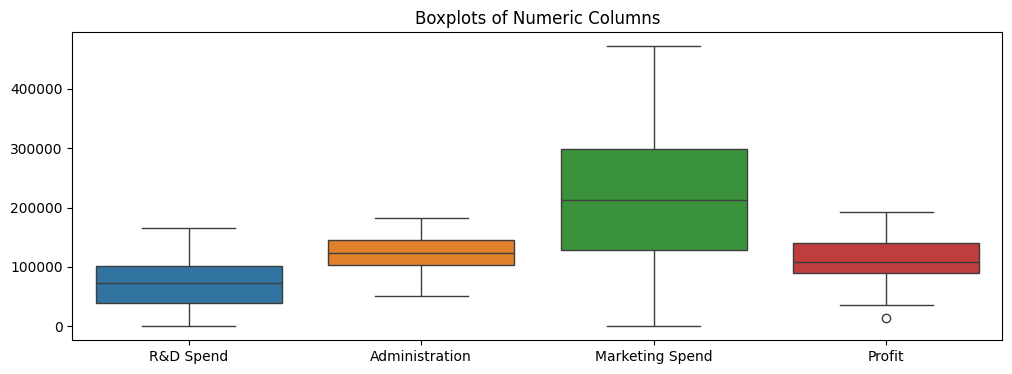

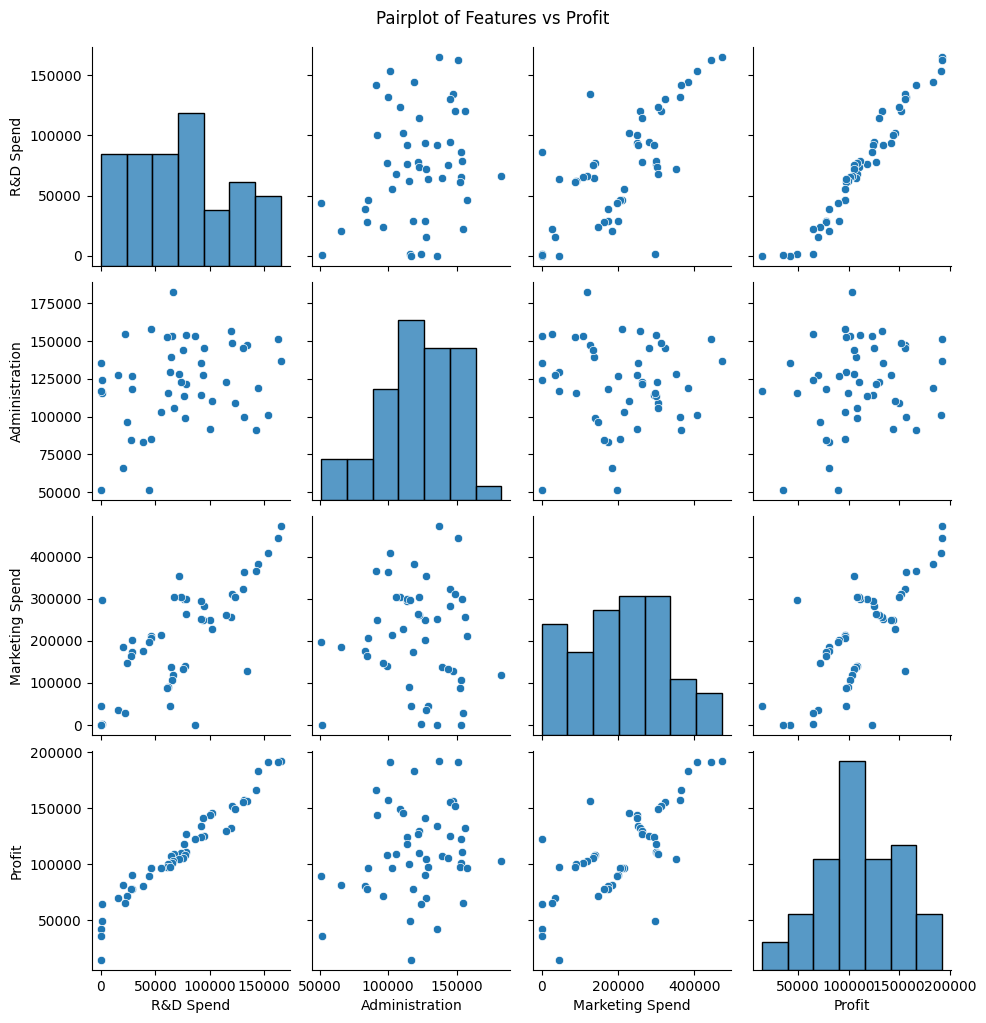

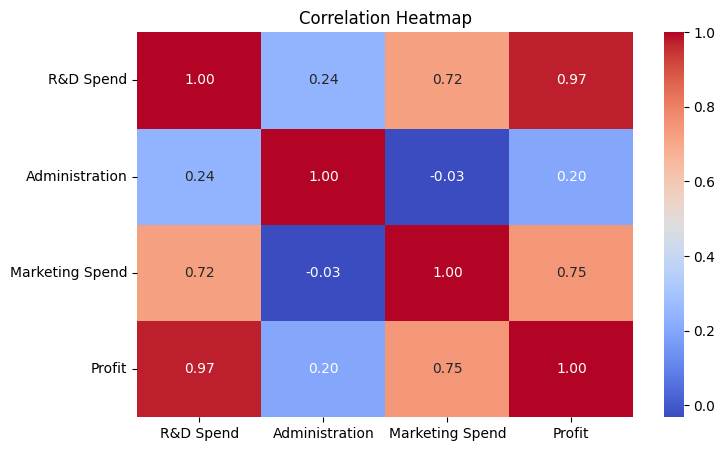

In [ ]:
# 1) SIMPLE SEABORN PLOTS FOR ALL FEATURES
plt.figure(figsize=(12,4))
sns.boxplot(data=df[['R&D Spend','Administration','Marketing Spend','Profit']])
plt.title("Boxplots of Numeric Columns")
plt.show()

sns.pairplot(df[['R&D Spend','Administration','Marketing Spend','Profit']])
plt.suptitle("Pairplot of Features vs Profit", y=1.02)
plt.show()

plt.figure(figsize=(8,5))
sns.heatmap(df[['R&D Spend','Administration','Marketing Spend','Profit']].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
# -------------------------
# 2) ONE-HOT ENCODING
# -------------------------
data = pd.get_dummies(df, columns=['State'], drop_first=True)

# Keep names for later
feature_cols_all = [c for c in data.columns if c != 'Profit']
X_raw_all = data[feature_cols_all].astype(float).values
y_raw = data['Profit'].astype(float).values

In [ ]:
# -------------------------
# 3) TRAIN / TEST SPLIT (manual, no sklearn)
# -------------------------
np.random.seed(42)
idx = np.arange(len(X_raw_all))
np.random.shuffle(idx)
train_n = int(0.8 * len(idx))
train_idx, test_idx = idx[:train_n], idx[train_n:]

X_train_raw, X_test_raw = X_raw_all[train_idx], X_raw_all[test_idx]
y_train_raw, y_test_raw = y_raw[train_idx], y_raw[test_idx]

# Standardize using TRAINING stats only (safer)
eps = 1e-8
X_mean, X_std = X_train_raw.mean(axis=0), X_train_raw.std(axis=0) + eps
y_mean, y_std = y_train_raw.mean(), y_train_raw.std() + eps

X_train = (X_train_raw - X_mean) / X_std
y_train = (y_train_raw - y_mean) / y_std
X_test  = (X_test_raw  - X_mean) / X_std
y_test  = (y_test_raw  - y_mean) / y_std

# Add bias
X_train_b = np.c_[np.ones((X_train.shape[0], 1)), X_train]
X_test_b  = np.c_[np.ones((X_test.shape[0], 1)),  X_test]

m_train, n_params = X_train_b.shape  # n_params = 1 + num_features

In [ ]:
# 4) GRADIENT DESCENT (no sklearn)
# -------------------------
def compute_cost(X, y, theta):
    """MSE/2 cost on (possibly) scaled data."""
    err = X @ theta - y
    return (err @ err) / (2 * len(y))

def gradient_descent(X, y, theta0=None, alpha=0.1, iters=500, record_path=False):
    """Basic batch gradient descent. Optionally record theta path."""
    m, n = X.shape
    theta = np.zeros(n) if theta0 is None else theta0.astype(float).copy()
    history = []
    path = []
    for _ in range(iters):
        if record_path: path.append(theta.copy())
        grad = (X.T @ (X @ theta - y)) / m
        theta -= alpha * grad
        history.append(compute_cost(X, y, theta))
    if record_path: path.append(theta.copy())
    return theta, np.array(history), (np.array(path) if record_path else None)


In [ ]:
# 7) SET A LEARNING RATE (you can change this later)
alpha = 0.1
iters = 1000

theta_scaled, cost_hist, theta_path = gradient_descent(X_train_b, y_train, alpha=alpha, iters=iters, record_path=True)

print("Theta (scaled space):")
print(theta_scaled)

Theta (scaled space):
[-0.          0.92551857  0.01762946  0.0786772   0.00707955 -0.03595801]


In [ ]:
# 5) CONVERT θ BACK TO ORIGINAL UNITS + PRINT THE EQUATION
# -------------------------
# scaled model used: y_s = theta0 + sum_j theta_j * x_sj
# unscaled: y = b0 + sum_j b_j * x_j, where:
# b_j = theta_j * (y_std / X_std_j)
# b0  = y_mean + y_std*theta0 - sum_j (b_j * X_mean_j)

theta_real = np.zeros_like(theta_scaled)
theta_real[1:] = theta_scaled[1:] * (y_std / X_std)
theta_real[0]  = y_mean + y_std*theta_scaled[0] - np.sum(theta_real[1:] * X_mean)

# Feature names in same order as X_raw_all (after get_dummies)
feature_names = feature_cols_all

print("\nTheta in ORIGINAL UNITS:")
print(f"Intercept: {theta_real[0]:.4f}")
for name, val in zip(feature_names, theta_real[1:]):
    print(f"{name}: {val:.6f}")

# 5) Equation: show both scaled and original-unit equations
# Scaled equation:
eq_scaled = "y_scaled = " + f"{theta_scaled[0]:.4f} " + " ".join(
    [("+ " if c>=0 else "- ") + f"{abs(c):.4f}*({name}_scaled)" for name, c in zip(feature_names, theta_scaled[1:])]
)
print("\nRegression Equation (on SCALED data):")
print(eq_scaled)

# Original-units equation:
eq_real = "Profit = " + f"{theta_real[0]:.2f} " + " ".join(
    [("+ " if c>=0 else "- ") + f"{abs(c):.6f}*({name})" for name, c in zip(feature_names, theta_real[1:])]
)
print("\nRegression Equation (ORIGINAL units):")
print(eq_real)


Theta in ORIGINAL UNITS:
Intercept: 46867.3927
R&D Spend: 0.796893
Administration: 0.026153
Marketing Spend: 0.024560
State_Florida: 652.319984
State_New York: -2928.501211

Regression Equation (on SCALED data):
y_scaled = -0.0000 + 0.9255*(R&D Spend_scaled) + 0.0176*(Administration_scaled) + 0.0787*(Marketing Spend_scaled) + 0.0071*(State_Florida_scaled) - 0.0360*(State_New York_scaled)

Regression Equation (ORIGINAL units):
Profit = 46867.39 + 0.796893*(R&D Spend) + 0.026153*(Administration) + 0.024560*(Marketing Spend) + 652.319984*(State_Florida) - 2928.501211*(State_New York)


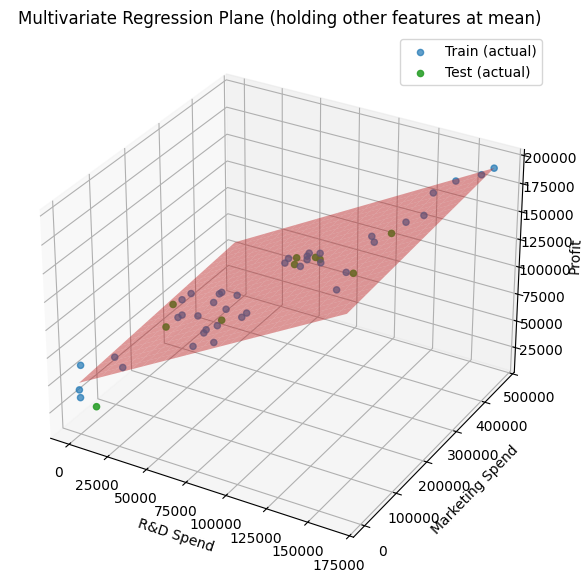

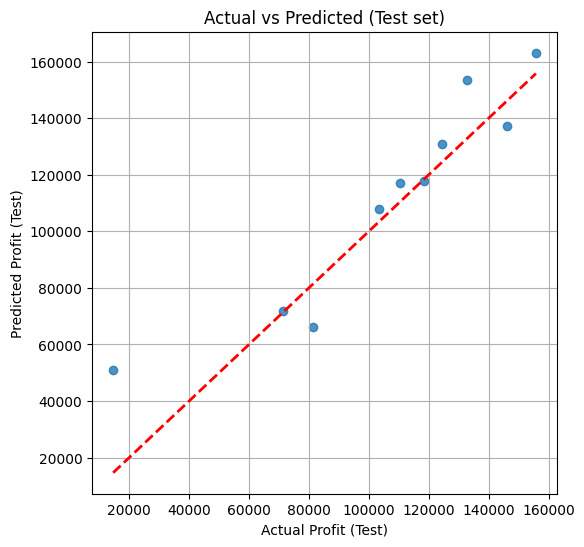

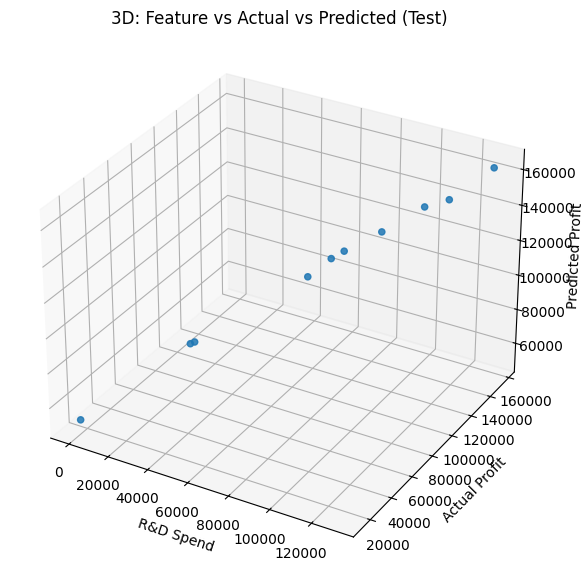

In [ ]:
# 6) 3D PLANE MULTIVARIATE GRAPH (pick 2 features; hold others at mean)
# -------------------------
# choose two numeric features to visualize
# here we use 'R&D Spend' and 'Marketing Spend' if present
def ensure_feature(name):
    if name not in feature_names:
        raise ValueError(f"Feature '{name}' not found. Available: {feature_names}")

f1 = 'R&D Spend'
f2 = 'Marketing Spend'
ensure_feature(f1); ensure_feature(f2)
i1, i2 = feature_names.index(f1), feature_names.index(f2)

# grid in original units
f1_lin = np.linspace(df[f1].min(), df[f1].max(), 25)
f2_lin = np.linspace(df[f2].min(), df[f2].max(), 25)
F1, F2 = np.meshgrid(f1_lin, f2_lin)

# build plane prediction in original units, keeping other features at their TRAIN means
# (use training-set means to be consistent)
other_sum = 0.0
for j, name in enumerate(feature_names):
    if j not in (i1, i2):
        other_sum += theta_real[j+1] * X_mean[j]  # (+1 offset because theta_real[0] is intercept)

Z_plane = theta_real[0] + theta_real[i1+1]*F1 + theta_real[i2+1]*F2 + other_sum

# scatter actual points (original units)
fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_train_raw[:, i1], X_train_raw[:, i2], y_train_raw, c='tab:blue', label='Train (actual)', alpha=0.7)
ax.scatter(X_test_raw[:,  i1], X_test_raw[:,  i2],  y_test_raw,  c='tab:green', label='Test (actual)',  alpha=0.9)
ax.plot_surface(F1, F2, Z_plane, alpha=0.45, color='tab:red')
ax.set_xlabel(f1); ax.set_ylabel(f2); ax.set_zlabel("Profit")
ax.set_title("Multivariate Regression Plane (holding other features at mean)")
ax.legend()
plt.show()

# -------------------------
# Predict and plot Actual vs Predicted (2D & 3D variants)
# -------------------------
# predictions in original units
y_pred_train = theta_real[0] + X_train_raw @ theta_real[1:]
y_pred_test  = theta_real[0] + X_test_raw  @ theta_real[1:]

# 2D Actual vs Predicted (Test)
plt.figure(figsize=(6,6))
plt.scatter(y_test_raw, y_pred_test, alpha=0.8)
plt.plot([y_test_raw.min(), y_test_raw.max()],
         [y_test_raw.min(), y_test_raw.max()], 'r--', lw=2)
plt.xlabel("Actual Profit (Test)"); plt.ylabel("Predicted Profit (Test)")
plt.title("Actual vs Predicted (Test set)")
plt.grid(True); plt.show()

# 3D Actual vs Predicted (Test) using one feature on X
feature_for_3d = f1  # you can change to f2 or any other
fi = feature_names.index(feature_for_3d)
fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_test_raw[:, fi], y_test_raw, y_pred_test, alpha=0.85)
ax.set_xlabel(feature_for_3d); ax.set_ylabel("Actual Profit"); ax.set_zlabel("Predicted Profit")
ax.set_title("3D: Feature vs Actual vs Predicted (Test)")
plt.show()

# -------------------------

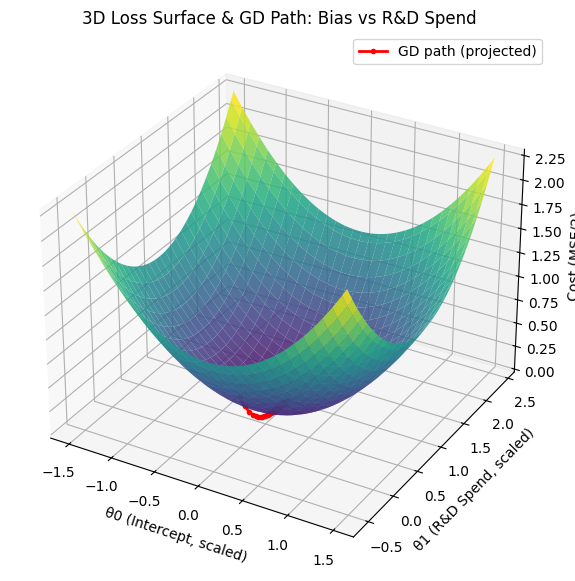

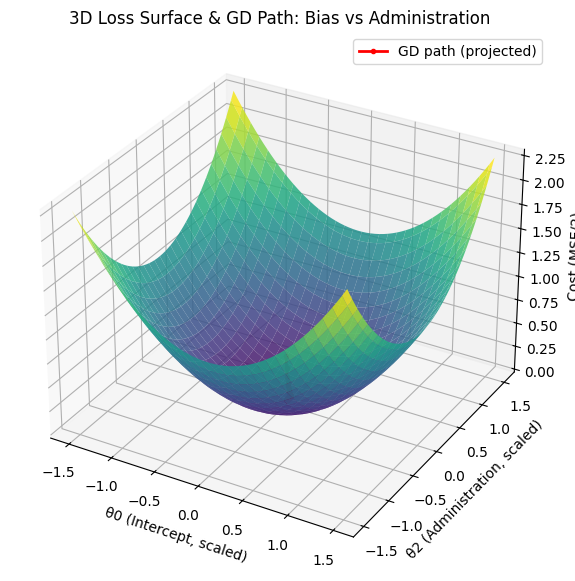

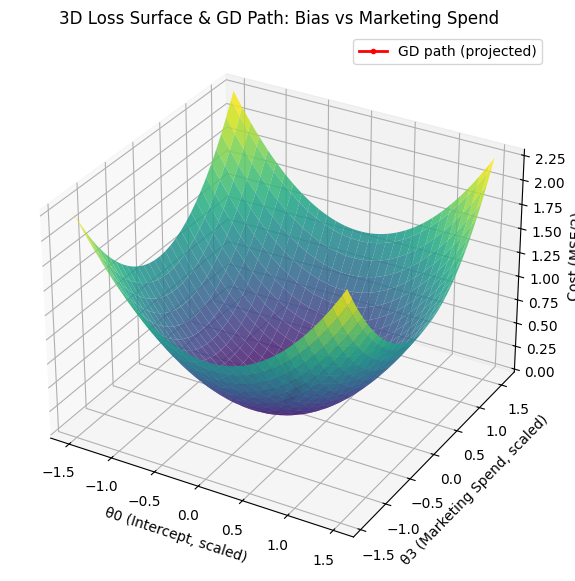

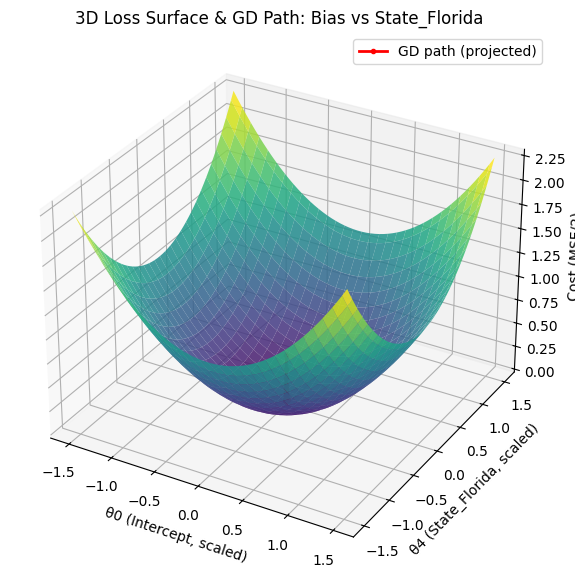

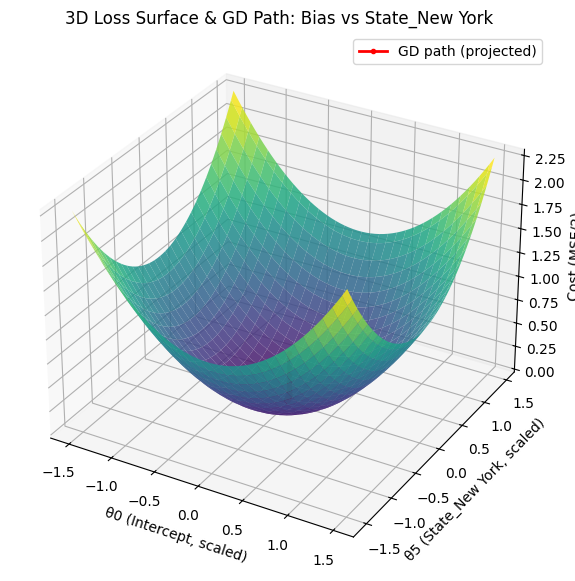

In [ ]:
# 8) 3D GRADIENT DESCENT: LOSS SURFACE + PATH (for EACH feature vs bias)
# -------------------------
# We visualize in the (theta0, theta_j) plane (scaled space),
# keeping other thetas fixed at the optimized values. The path we show
# is the projection of the full GD path onto that plane.

def plot_loss_surface_and_path_for_feature(j, j_name, theta_opt_scaled, Xb, y, theta_path_full):
    # Ranges around optimum in scaled space
    t0_c = theta_opt_scaled[0]
    tj_c = theta_opt_scaled[j]
    t0_vals = np.linspace(t0_c - 1.5, t0_c + 1.5, 60)
    tj_vals = np.linspace(tj_c - 1.5, tj_c + 1.5, 60)

    # Prepare cost grid by varying only (theta0, theta_j)
    T0, TJ = np.meshgrid(t0_vals, tj_vals)
    cost_grid = np.zeros_like(T0)

    base = theta_opt_scaled.copy()
    for r in range(T0.shape[0]):
        for c in range(T0.shape[1]):
            th = base.copy()
            th[0] = T0[r,c]
            th[j] = TJ[r,c]
            cost_grid[r,c] = compute_cost(Xb, y, th)

    # Project the recorded path to (theta0, theta_j)
    path_t0 = theta_path_full[:, 0]
    path_tj = theta_path_full[:, j]
    path_cost = np.array([compute_cost(Xb, y, th) for th in theta_path_full])

    # Plot surface + path
    fig = plt.figure(figsize=(9,7))
    ax = fig.add_subplot(111, projection='3d')
    ax.plot_surface(T0, TJ, cost_grid, cmap='viridis', alpha=0.85)
    ax.plot(path_t0, path_tj, path_cost, 'r-o', ms=3, lw=2, label='GD path (projected)')
    ax.set_xlabel("θ0 (Intercept, scaled)")
    ax.set_ylabel(f"θ{j} ({j_name}, scaled)")
    ax.set_zlabel("Cost (MSE/2)")
    ax.set_title(f"3D Loss Surface & GD Path: Bias vs {j_name}")
    ax.legend()
    plt.show()

# Loop over each feature index j = 1..n_params-1
for j, name in enumerate(feature_names, start=1):
    plot_loss_surface_and_path_for_feature(j, name, theta_scaled, X_train_b, y_train, theta_path)


In [ ]:
# 9) NEW THETA VALUES (after GD): already in theta_scaled/theta_real
#    Printing again for clarity
# -------------------------
print("\nFinal θ (scaled):", theta_scaled)
print("\nFinal θ (original units):")
print(f"Intercept: {theta_real[0]:.4f}")
for name, val in zip(feature_names, theta_real[1:]):
    print(f"{name}: {val:.6f}")


Final θ (scaled): [-0.          0.92551857  0.01762946  0.0786772   0.00707955 -0.03595801]

Final θ (original units):
Intercept: 46867.3927
R&D Spend: 0.796893
Administration: 0.026153
Marketing Spend: 0.024560
State_Florida: 652.319984
State_New York: -2928.501211


In [ ]:
# 10) TRY DIFFERENT LEARNING RATES & COMPARE THETAS
# -------------------------
def train_with_alpha(alpha_val, iters=1000):
    th, hist, _ = gradient_descent(X_train_b, y_train, alpha=alpha_val, iters=iters, record_path=False)
    # convert to original units
    th_real = np.zeros_like(th)
    th_real[1:] = th[1:] * (y_std / X_std)
    th_real[0]  = y_mean + y_std*th[0] - np.sum(th_real[1:] * X_mean)
    return th, th_real, hist

alphas_to_try = [0.001, 0.01, 0.05, 0.1, 0.2,1.0]
theta_results = []

print("\n=== Learning rate sweep ===")
for a in alphas_to_try:
    th_s, th_r, hist = train_with_alpha(a, iters=1000)
    theta_results.append((a, th_s, th_r, hist[-1]))
    print(f"alpha={a:<6} | final cost={hist[-1]:.6f}")

# Show a quick table of original-unit thetas per alpha
print("\nTheta (original units) by learning rate:")
header = ["alpha", "Intercept"] + feature_names
print("\t".join(header))
for a, th_s, th_r, c in theta_results:
    row = [f"{a}"] + [f"{th_r[0]:.2f}"] + [f"{v:.6f}" for v in th_r[1:]]
    print("\t".join(row))


=== Learning rate sweep ===
alpha=0.001  | final cost=0.055683
alpha=0.01   | final cost=0.016009
alpha=0.05   | final cost=0.015628
alpha=0.1    | final cost=0.015628
alpha=0.2    | final cost=0.015628
alpha=1.0    | final cost=0.015628

Theta (original units) by learning rate:
alpha	Intercept	R&D Spend	Administration	Marketing Spend	State_Florida	State_New York
0.001	47378.53	0.436891	0.109200	0.098121	-954.979220	380.758788
0.01	45386.42	0.762787	0.040027	0.036879	-119.508838	-3013.458958
0.05	46867.26	0.796890	0.026154	0.024561	652.246071	-2928.512778
0.1	46867.39	0.796893	0.026153	0.024560	652.319984	-2928.501211
0.2	46867.39	0.796893	0.026153	0.024560	652.319985	-2928.501211
1.0	46867.39	0.796893	0.026153	0.024560	652.319985	-2928.501211
